<a href="https://colab.research.google.com/github/AvichalTrivedi7/IIT-Roorkee_InternshipWork/blob/main/Module_2_(Exercise_2_1)_IITR_Internship.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
# Timestep Embedding (minimal, for this exercise) (full sinusoidal embedding is in exercise 2.2)

import torch
import torch.nn as nn

class TimestepEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.linear = nn.Sequential(
            nn.Linear(1, dim),
            nn.SiLU(),
            nn.Linear(dim, dim)
        )

    def forward(self, t):
        # t: scalar int or (B,) tensor of timesteps
        t = t.float().view(-1, 1) / 999.0   # normalize to [0, 1]
        return self.linear(t)               # (B, dim)

In [7]:
#  The ResNet Block with AdaGN

class ResBlockAdaGN(nn.Module):
    def __init__(self, channels, t_emb_dim, num_groups=32):
        super().__init__()

        # GroupNorm — normalizes the feature map
        self.norm = nn.GroupNorm(num_groups=num_groups, num_channels=channels)

        # AdaGN projection — produces scale and shift from timestep embedding
        # Output is 2 * channels: first half = scale, second half = shift
        self.t_proj = nn.Linear(t_emb_dim, 2 * channels)

        # Activation
        self.act = nn.SiLU()

        # Convolution
        self.conv = nn.Conv2d(channels, channels, kernel_size=3, padding=1)

        # No residual projection needed here since in_channels == out_channels

    def forward(self, h, t_emb):
        """
        h:     (B, C, H, W) — feature map
        t_emb: (B, t_emb_dim) — timestep embedding vector
        """
        residual = h

        # Step 1: GroupNorm
        h = self.norm(h)

        # Step 2: AdaGN — scale and shift from timestep
        t_out = self.t_proj(t_emb)             # (B, 2C)
        scale, shift = t_out.chunk(2, dim=-1)  # each (B, C)

        # Reshape for broadcasting over H, W
        scale = scale.unsqueeze(-1).unsqueeze(-1)   # (B, C, 1, 1)
        shift = shift.unsqueeze(-1).unsqueeze(-1)   # (B, C, 1, 1)

        h = scale * h + shift

        # Step 3: SiLU activation
        h = self.act(h)

        # Step 4: Convolution
        h = self.conv(h)

        # Step 5: Residual addition
        return h + residual

In [8]:
# Freeze Weights and Test

torch.manual_seed(42)

# Dimensions
C = 64          # channels
T_DIM = 128     # timestep embedding dimension
B = 1           # batch size
H, W = 16, 16   # spatial size

# Instantiate
t_embedder = TimestepEmbedding(dim=T_DIM)
block = ResBlockAdaGN(channels=C, t_emb_dim=T_DIM)

# Freeze ALL weights — nothing will update
for param in block.parameters():
    param.requires_grad_(False)
for param in t_embedder.parameters():
    param.requires_grad_(False)

# Fixed input feature map — identical for all three runs
h_fixed = torch.randn(B, C, H, W)
h_fixed_copy = h_fixed.clone()   # confirm it never changes

# Run for t = 0, 500, 999
timesteps = [0, 500, 999]
results = {}

for t_val in timesteps:
    t_tensor = torch.tensor([t_val])
    t_emb = t_embedder(t_tensor)           # (1, T_DIM)
    with torch.no_grad():
        out = block(h_fixed.clone(), t_emb)
    results[t_val] = out

    print(f"t = {t_val:>4d} | "
          f"mean = {out.mean().item():+.6f} | "
          f"std = {out.std().item():.6f}")

# Confirm input never changed
assert torch.allclose(h_fixed, h_fixed_copy), "Input was modified!"
print("\nInput feature map was NOT modified — timestep alone changed the output.")

t =    0 | mean = +0.000231 | std = 1.011581
t =  500 | mean = -0.002316 | std = 1.011959
t =  999 | mean = -0.004992 | std = 1.013074

Input feature map was NOT modified — timestep alone changed the output.


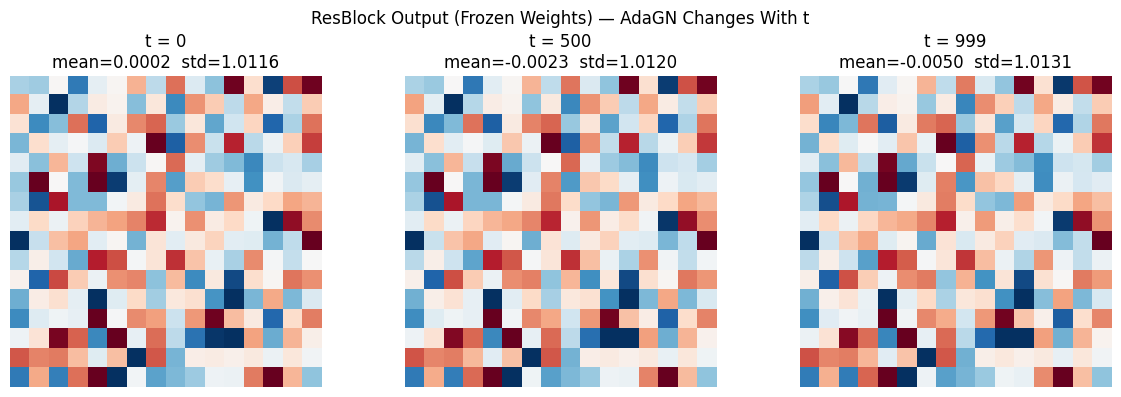

In [9]:
# Visualise the Difference (optional but good)

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for i, t_val in enumerate(timesteps):
    # Take channel 0 of the output, squeeze batch dim
    img = results[t_val][0, 0].numpy()
    axes[i].imshow(img, cmap='RdBu', vmin=-2, vmax=2)
    axes[i].set_title(f't = {t_val}\nmean={results[t_val].mean():.4f}  '
                      f'std={results[t_val].std():.4f}')
    axes[i].axis('off')

plt.suptitle('ResBlock Output (Frozen Weights) — AdaGN Changes With t', fontsize=12)
plt.tight_layout()
plt.savefig('exercise_2_1.png', dpi=150)
plt.show()

# Interpretation and Observation

#### The experiment shows that a residual block with Adaptive Group Normalisation produces distinct output distributions for t=0, t=500, and t=999 even when every learnable weight is frozen and the input feature map is byte-identical across all three runs. This happens because AdaGN replaces the fixed scale and shift parameters of standard GroupNorm with values dynamically projected from the timestep embedding — so the normalisation layer itself becomes a function of t rather than a constant. The residual addition ensures the block never loses access to the original feature map regardless of how the normalisation behaves, which is why the output differences are controlled rather than chaotic. In the context of LDAE's U-Net, this mechanism is critical: the same convolutional weights must serve across all 1000 timesteps, and AdaGN is what allows the network to adapt its internal representations to the noise level of its input without needing separate parameters for each t.

Additional Observation - The output statistics shift with each timestep (mean moves from +0.0002 to −0.0050, std from 1.0116 to 1.0131) confirming that AdaGN is genuinely modulating the block's output through timestep-conditioned scale and shift. The change is subtle here because the embedding is randomly initialized and untrained - in a fully trained U-Net, the sinusoidal embedding and optimized t_proj weights produce much more pronounced conditioning signals that the network learns to exploit for noise-level-aware feature extraction.

Pipeline - h (feature map) → GroupNorm (basic normalization u=0, var.=1) → AdaGN(scale & shift from t) → SiLU ("swish" activation function, allows slight negative values to go through as well. formula --> x.sigmoid(x)) → Conv2d → + h(residual)

#In layman terms my understanding -

As far as i have understood, h feature map is extracted from the image ofcourse as the first step, then the vector of the image (feature map) is normalized, then AdaGN model does the adaptive normalization which is different for every timestep t, then we have silu which introduces non linearity and helps model learn complex things just like any other activation function, then the conv2d model learns the patterns and everything going through what we have made until now, then we have the final output on top of which we add the original h so that the difference is outputted and when the model is re adjusting weights after all this it doesn't go to smaller and smaller outputs because of gradient and overall decay of our stuff.(Basically, The + h reconstructs the full output. The gradient benefit follows from this, because the + h path always carries a clean gradient straight back to early layers regardless of what F(h) does.)